# Preparação e análise de dados para redes neurais

**Atividade 1 — Data | Espalhamento, geometria e pré-processamento**

Este relatório compara nuvens gaussianas em 2D, duas estruturas de classes em 5D
e a preparação do Spaceship Titanic para uma rede com ativação `tanh`.
Nenhum modelo preditivo é treinado: as fronteiras desenhadas e as regras de
comparação são calculadas diretamente a partir da geometria e dos parâmetros dados.

**Reprodutibilidade.** Execute `python docs/exercises/data/code/analise.py` da raiz
do repositório após instalar `requirements.txt`. O script executa os blocos na ordem;
o notebook complementar pode ser executado em um kernel novo.
Há um único `rng = np.random.default_rng(42)`, compartilhado por todas as gerações
e pelo split. A PCA usa SVD completa, determinística. O arquivo `data/train.csv`
acompanha o projeto; seu hash é conferido antes da leitura. As bibliotecas científicas
são exclusivamente as permitidas; os utilitários Jupyter servem apenas para montar
o notebook e exportar este relatório. Os resultados abaixo foram calculados, e os
valores também estão escritos nas análises e no resumo final.

In [1]:
from pathlib import Path
from itertools import combinations
import hashlib
import json
import platform
import os

# Caminhos independentes da pasta atual: funciona em um clone limpo.
if "__file__" in globals():
    EXERCISE_DIR = Path(__file__).resolve().parent.parent
else:
    # Jupyter: aberto em code/, na pasta do exercício ou na raiz do repositório.
    candidatos = [Path.cwd().parent, Path.cwd(), Path.cwd() / "docs/exercises/data"]
    EXERCISE_DIR = next(p for p in candidatos if (p / "data/train.csv").is_file())
os.environ.setdefault("MPLCONFIGDIR", str(EXERCISE_DIR.parents[2] / ".cache/matplotlib"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import sklearn
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Único gerador: não reinicializar nem criar outras sementes nos exercícios.
rng = np.random.default_rng(42)
OUT = EXERCISE_DIR / "resultados"
FIG = EXERCISE_DIR / "figures"
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)
CORES = ["#2463A6", "#D97720", "#269477", "#9656A6"]
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 180, "font.size": 10,
    "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.17, "legend.framealpha": 0.95,
})

def salvar_figura(fig, numero):
    fig.savefig(FIG / f"figura_{numero}.png", bbox_inches="tight", facecolor="white")
    if matplotlib.get_backend().lower() != "agg":
        plt.show()
    plt.close(fig)

versoes = {"Python": platform.python_version(), "numpy": np.__version__,
           "pandas": pd.__version__, "matplotlib": matplotlib.__version__,
           "scikit-learn": sklearn.__version__}
print("Versões usadas:", versoes)

Versões usadas: {'Python': '3.13.4', 'numpy': '2.5.3', 'pandas': '3.0.5', 'matplotlib': '3.11.1', 'scikit-learn': '1.9.1'}


## Exercício 1

### A — Gere as nuvens

Cada classe contém **100 pontos**, totalizando **400 amostras e duas features**.
As duas coordenadas são independentes dentro de cada gaussiana: suas covariâncias
são diagonais, com os quadrados dos desvios fornecidos. Os centros marcados na
Figura 1 são as **médias populacionais especificadas**, que não se confundem com
as médias amostrais. O esboço de fronteiras pedido em C aparece na própria figura.

| Classe | Média | Desvios padrão |
| --- | --- | --- |
| 0 | [2, 3] | [0,8; 2,5] |
| 1 | [5, 6] | [1,2; 1,9] |
| 2 | [8, 1] | [0,9; 0,9] |
| 3 | [15, 4] | [0,5; 2,0] |

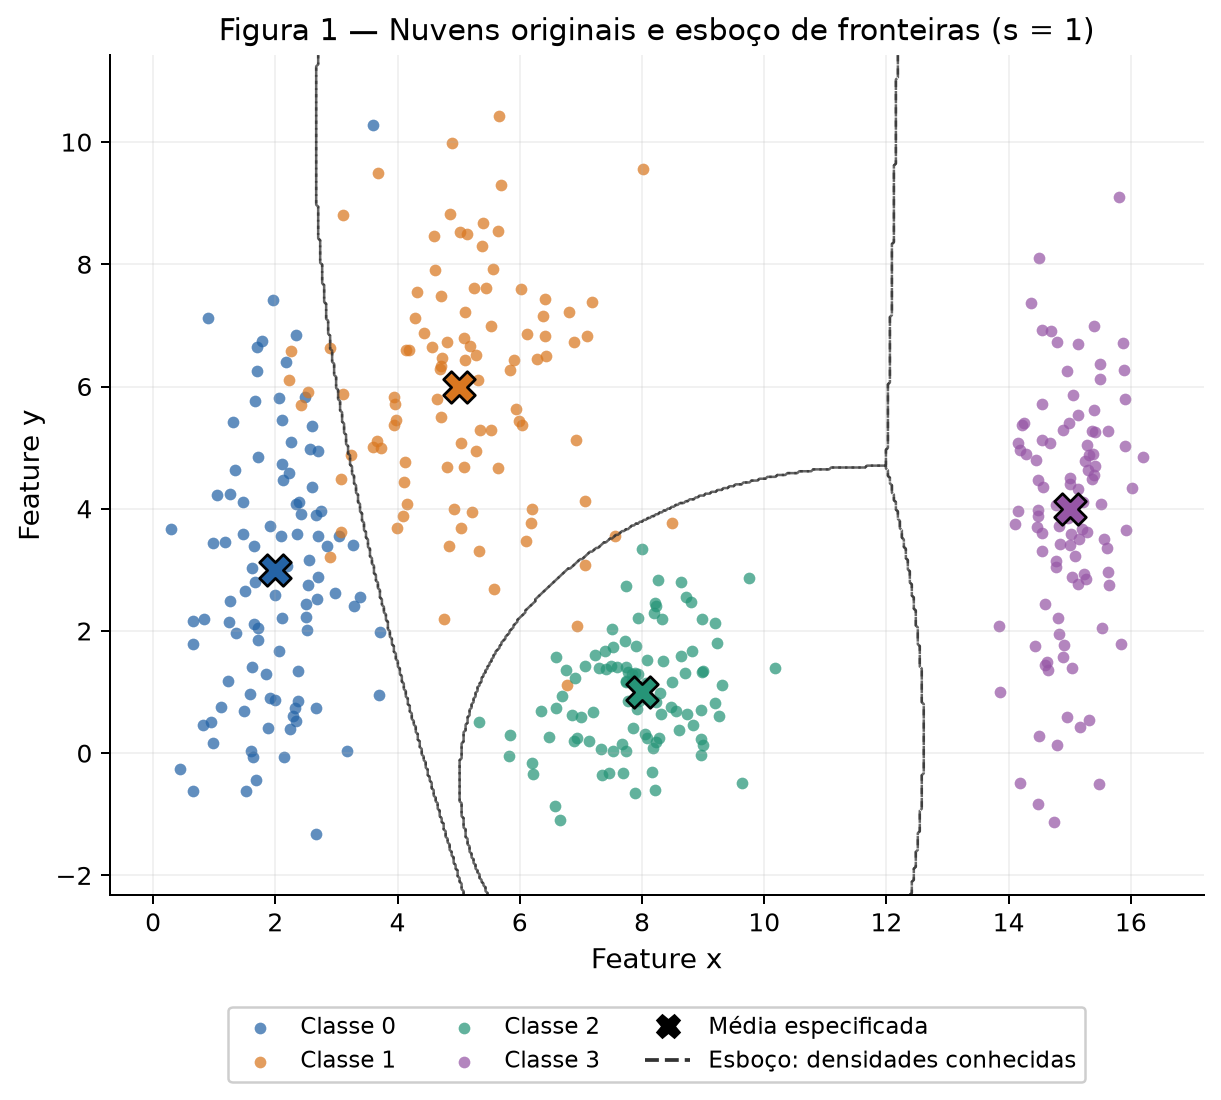

In [2]:
medias = np.array([[2, 3], [5, 6], [8, 1], [15, 4]], dtype=float)
desvios = np.array([[0.8, 2.5], [1.2, 1.9], [0.9, 0.9], [0.5, 2.0]])
y_2d = np.repeat(np.arange(4), 100)

def gerar_nuvens(s):
    return np.vstack([rng.normal(mu, s * sd, size=(100, 2))
                      for mu, sd in zip(medias, desvios)])

X_original = gerar_nuvens(1.0)
assert X_original.shape == (400, 2)
assert np.array_equal(np.bincount(y_2d), [100, 100, 100, 100])

def desenhar_nuvens(ax, X, centros=True):
    for k, cor in enumerate(CORES):
        ax.scatter(*X[y_2d == k].T, s=22, color=cor, alpha=0.72,
                   label=f"Classe {k}", linewidths=0)
        if centros:
            ax.scatter(*medias[k], s=160, marker="X", c=cor,
                       edgecolor="black", linewidth=1.1, zorder=5)
    ax.set_xlabel("Feature x")
    ax.set_ylabel("Feature y")
    ax.set_aspect("equal", adjustable="box")

fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
desenhar_nuvens(ax, X_original)
xlim = (X_original[:, 0].min() - 1, X_original[:, 0].max() + 1)
ylim = (X_original[:, 1].min() - 1, X_original[:, 1].max() + 1)
gx, gy = np.meshgrid(np.linspace(*xlim, 550), np.linspace(*ylim, 450))
grade = np.column_stack([gx.ravel(), gy.ravel()])
# Esboço pelas densidades gaussianas conhecidas e priors iguais.
# Menor escore = maior densidade. Não há ajuste ou treinamento.
escores = (((grade[:, None, :] - medias) / desvios) ** 2).sum(axis=2)
escores += 2 * np.log(desvios).sum(axis=1)
regioes = escores.argmin(axis=1).reshape(gx.shape)
for k in range(4):
    ax.contour(gx, gy, (regioes == k).astype(float), levels=[0.5],
               colors=["#333333"], linewidths=1, linestyles="--", alpha=0.75)
ax.set(xlim=xlim, ylim=ylim, title="Figura 1 — Nuvens originais e esboço de fronteiras (s = 1)")
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([], [], marker="X", color="black", linestyle="None", markersize=9),
            Line2D([], [], color="#333333", linestyle="--")]
ax.legend(handles, labels + ["Média especificada", "Esboço: densidades conhecidas"],
          loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9)
salvar_figura(fig, 1)

### B — Mais ou menos espalhado

Construí **quatro datasets**, cada um com as quatro classes e 400 pontos.
O dataset de $s=1$ é exatamente o do item A. Para $s=0,5$, $s=2$ e $s=4$,
sorteei novas amostras, nessa ordem, continuando o mesmo `rng`; as médias
permanecem fixas e todos os desvios são multiplicados por $s$.
Assim, a comparação também contém a variabilidade das amostragens independentes.

A taxa de mistura compara distâncias euclidianas às **quatro médias especificadas**:
$m(s)=N^{-1}\sum_n 1[\arg\min_k\|x_n-\mu_k\|\ne y_n]$.
Isso é uma medida geométrica, sem estimar parâmetros ou treinar um classificador.

   Par  Distância dos centros  Soma dos desvios médios  r_ij em s=1
(0, 1)               4.242641                     3.20     1.325825
(0, 2)               6.324555                     2.55     2.480218
(0, 3)              13.038405                     2.90     4.496002
(1, 2)               5.830952                     2.45     2.379980
(1, 3)              10.198039                     2.80     3.642157
(2, 3)               7.615773                     2.15     3.542220
  s  Pontos misturados / 400  Taxa de mistura (%)
0.5                        0                 0.00
1.0                       20                 5.00
2.0                       77                19.25
4.0                      193                48.25


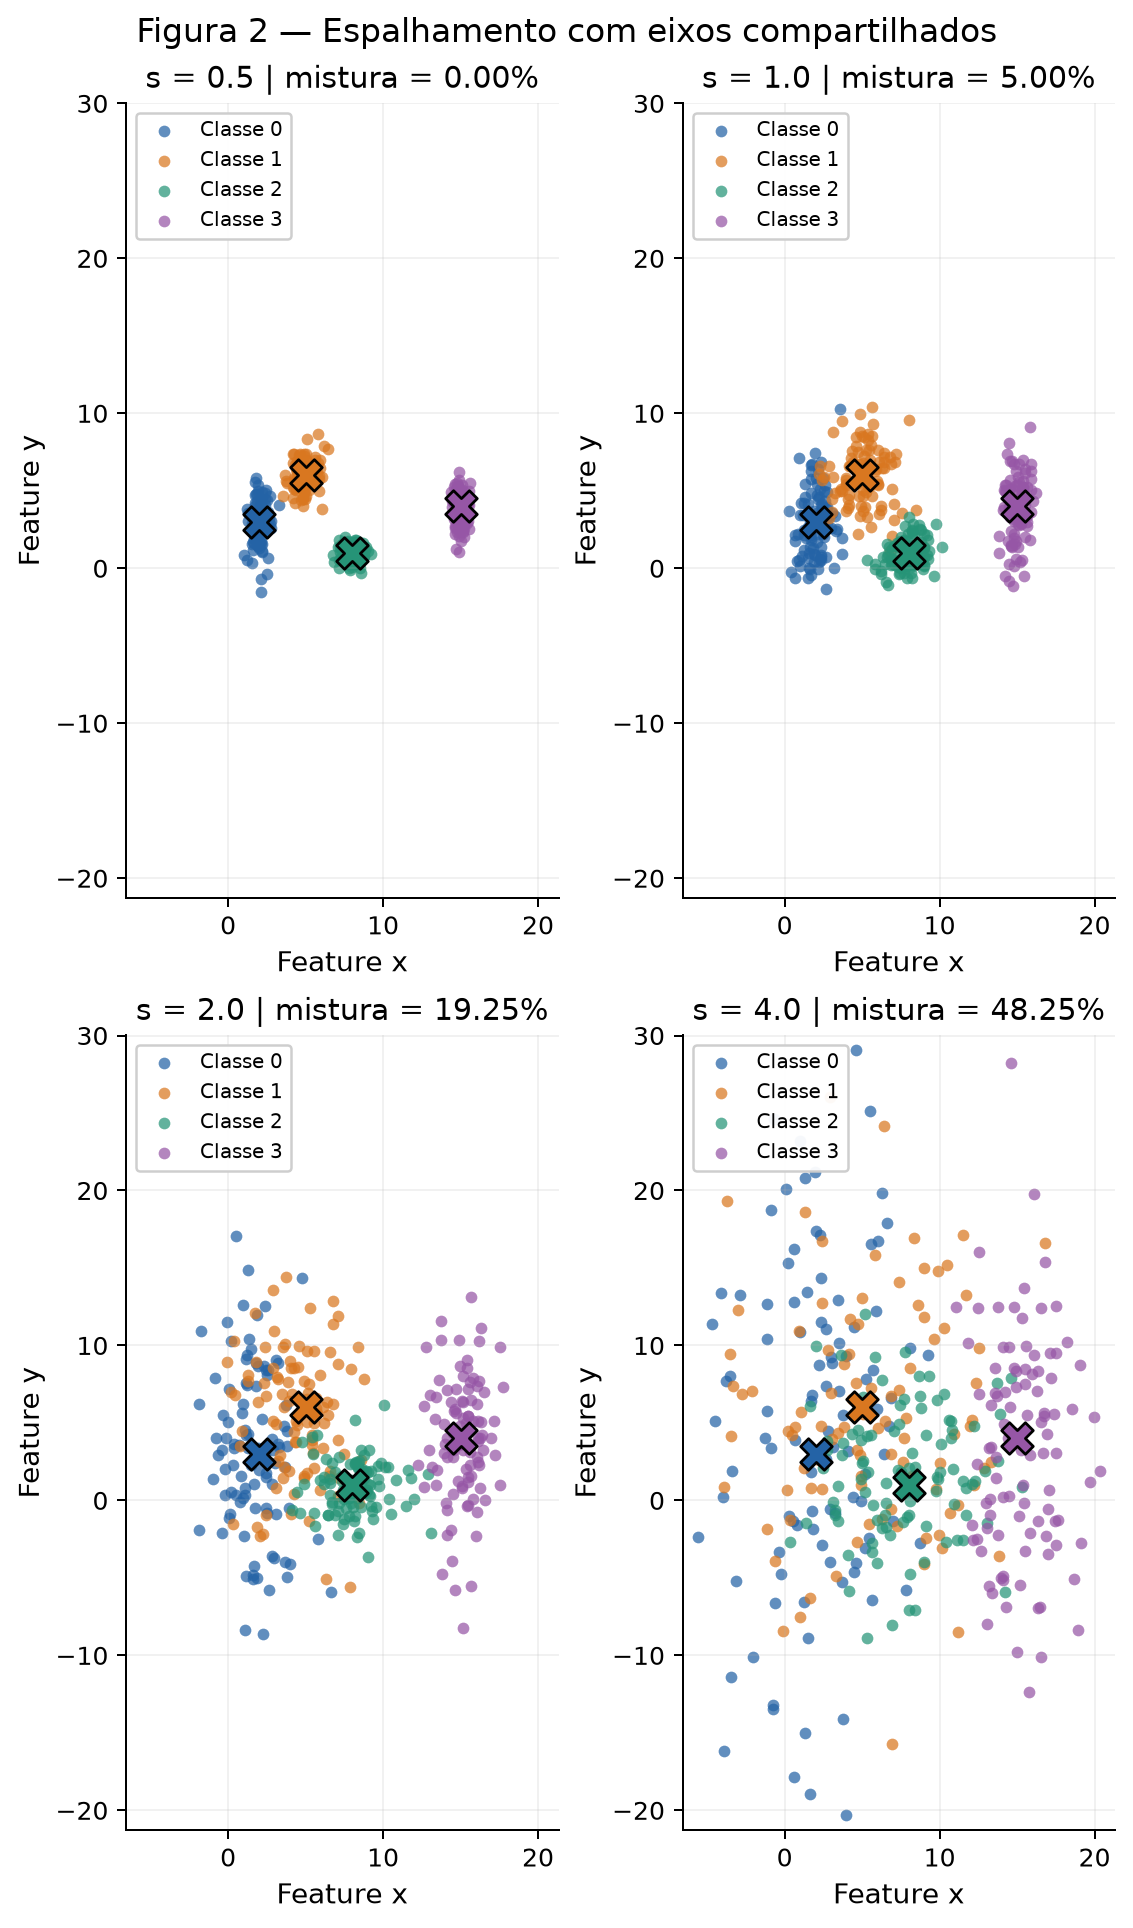

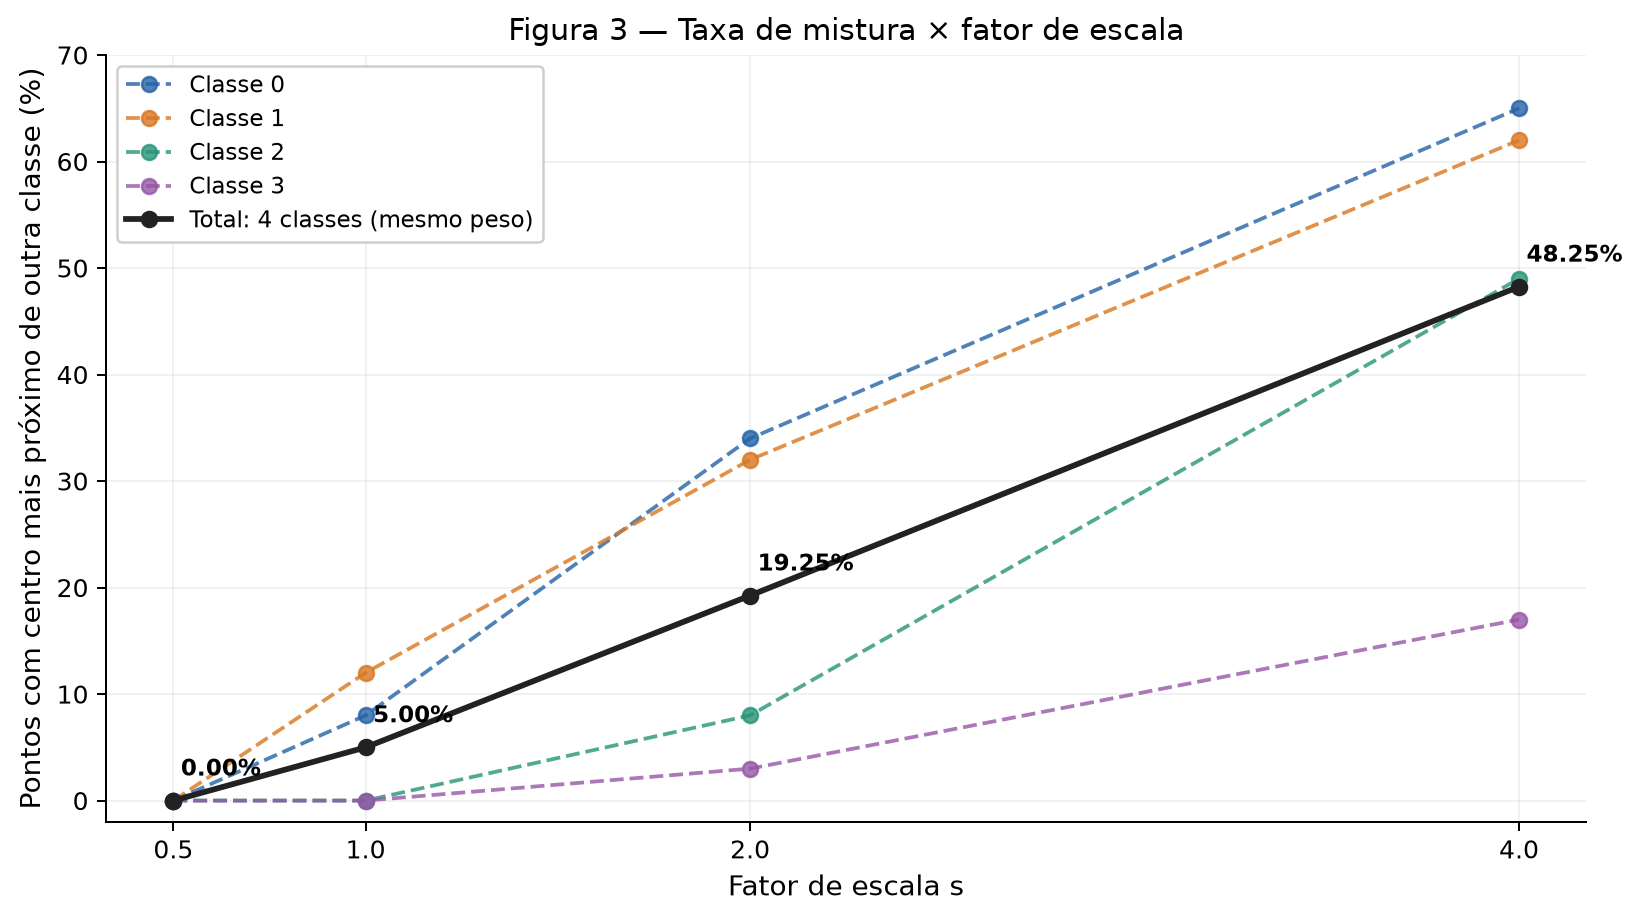

In [3]:
escalas = np.array([0.5, 1.0, 2.0, 4.0])
datasets_2d = {1.0: X_original}
for s in (0.5, 2.0, 4.0):
    datasets_2d[s] = gerar_nuvens(s)

pares = list(combinations(range(4), 2))
sd_medio = desvios.mean(axis=1)
rij = pd.DataFrame([
    {"Par": f"({i}, {j})", "Distância dos centros": np.linalg.norm(medias[i] - medias[j]),
     "Soma dos desvios médios": sd_medio[i] + sd_medio[j],
     "r_ij em s=1": np.linalg.norm(medias[i] - medias[j]) / (sd_medio[i] + sd_medio[j])}
    for i, j in pares
])
menor_linha = rij.loc[rij["r_ij em s=1"].idxmin()]
rmin = float(menor_linha["r_ij em s=1"])
par_min = menor_linha["Par"]

taxas, erros_mistura, taxas_classe = {}, {}, {}
for s in escalas:
    X = datasets_2d[s]
    d2 = ((X[:, None, :] - medias[None, :, :]) ** 2).sum(axis=2)
    diferente = d2.argmin(axis=1) != y_2d
    taxas[s] = diferente.mean()
    erros_mistura[s] = int(diferente.sum())
    taxas_classe[s] = [diferente[y_2d == k].mean() for k in range(4)]
mistura = pd.DataFrame({"s": escalas,
                       "Pontos misturados / 400": [erros_mistura[s] for s in escalas],
                       "Taxa de mistura (%)": [100 * taxas[s] for s in escalas]})

# Mesmos limites, mesma proporção x:y e todas as observações visíveis.
todos = np.vstack([datasets_2d[s] for s in escalas])
limites = np.column_stack([todos.min(axis=0) - 1, todos.max(axis=0) + 1])
fig, axes = plt.subplots(2, 2, figsize=(8.7, 10.6), sharex=True, sharey=True,
                         layout="compressed")
for ax, s in zip(axes.ravel(), escalas):
    desenhar_nuvens(ax, datasets_2d[s])
    ax.set(xlim=limites[0], ylim=limites[1],
           title=f"s = {s:.1f} | mistura = {100 * taxas[s]:.2f}%")
    ax.tick_params(labelbottom=True, labelleft=True)
    ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Figura 2 — Espalhamento com eixos compartilhados", fontsize=13)
salvar_figura(fig, 2)

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for k, cor in enumerate(CORES):
    ax.plot(escalas, [100 * taxas_classe[s][k] for s in escalas],
            "o--", color=cor, alpha=0.8, label=f"Classe {k}")
total = np.array([100 * taxas[s] for s in escalas])
ax.plot(escalas, total, "o-", color="#222222", lw=2.3,
        label="Total: 4 classes (mesmo peso)")
for s, valor in zip(escalas, total):
    ax.annotate(f"{valor:.2f}%", (s, valor), xytext=(3, 10),
                textcoords="offset points", fontsize=9, fontweight="bold")
ax.set(title="Figura 3 — Taxa de mistura × fator de escala",
       xlabel="Fator de escala s", ylabel="Pontos com centro mais próximo de outra classe (%)",
       xticks=escalas, ylim=(-2, max(70, total.max() + 15)))
ax.legend(fontsize=9)
salvar_figura(fig, 3)
print(rij.to_string(index=False))
print(mistura.to_string(index=False))

A razão usa os parâmetros populacionais: $r_{ij}=\|\mu_i-\mu_j\|/(\bar\sigma_i+\bar\sigma_j)$, com $\bar\sigma_k=(\sigma_{k,x}+\sigma_{k,y})/2$.

| Par | Distância dos centros | Soma dos desvios médios | r_ij em s=1 |
| --- | --- | --- | --- |
| (0, 1) | 4,2426 | 3,2000 | 1,3258 |
| (0, 2) | 6,3246 | 2,5500 | 2,4802 |
| (0, 3) | 13,0384 | 2,9000 | 4,4960 |
| (1, 2) | 5,8310 | 2,4500 | 2,3800 |
| (1, 3) | 10,1980 | 2,8000 | 3,6422 |
| (2, 3) | 7,6158 | 2,1500 | 3,5422 |

O menor valor é **1,3258, no par (0, 1)**, em $s=1$.
Como o denominador é multiplicado por $s$, o mínimo em $s=2$ vale
**0,6629**, sem nova geração ou estimação.

As taxas de mistura foram:

| s | Pontos misturados / 400 | Taxa de mistura (%) |
| --- | --- | --- |
| 0,50 | 0 | 0,00 |
| 1,00 | 20 | 5,00 |
| 2,00 | 77 | 19,25 |
| 4,00 | 193 | 48,25 |

Em texto: **0,00% em s=0,5; 5,00%
em s=1; 19,25% em s=2; e 48,25% em s=4**.
As linhas coloridas da Figura 3 decompõem a mesma medida por classe, enquanto
a linha preta é a taxa total solicitada.

**Verificação geométrica da separabilidade.** Uma taxa de mistura positiva, sozinha,
não prova que toda reta falha: a regra do centro mais próximo fixa fronteiras
particulares. Para decidir sobre a amostra 2D, calculo os **fechos convexos**
dos pontos de cada classe e verifico sua interseção. Dois conjuntos finitos
admitem separação estrita por uma reta se, e somente se, seus fechos convexos
são disjuntos. O código usa o algoritmo da cadeia monótona e as projeções nas
normais às arestas dos polígonos, apenas com NumPy, sem treinar modelos.

In [4]:
def fecho_convexo(pontos):
    # Vértices ordenados do menor polígono convexo que contém os pontos 2D.
    pts = sorted(set(map(tuple, pontos)))
    def cruz(a, b, c):
        return (b[0]-a[0])*(c[1]-a[1]) - (b[1]-a[1])*(c[0]-a[0])
    inferior, superior = [], []
    for p in pts:
        while len(inferior) >= 2 and cruz(inferior[-2], inferior[-1], p) <= 0:
            inferior.pop()
        inferior.append(p)
    for p in reversed(pts):
        while len(superior) >= 2 and cruz(superior[-2], superior[-1], p) <= 0:
            superior.pop()
        superior.append(p)
    return np.asarray(inferior[:-1] + superior[:-1])

def fechos_intersectam(a, b, tol=1e-10):
    # Teorema dos eixos separadores para dois polígonos convexos.
    for poligono in (a, b):
        arestas = np.roll(poligono, -1, axis=0) - poligono
        normais = np.column_stack([-arestas[:, 1], arestas[:, 0]])
        normais /= np.linalg.norm(normais, axis=1, keepdims=True)
        pa, pb = a @ normais.T, b @ normais.T
        separado = ((pa.max(axis=0) < pb.min(axis=0) - tol) |
                    (pb.max(axis=0) < pa.min(axis=0) - tol))
        if separado.any():
            return False
    return True

intersecoes = {}
for s in escalas:
    fechos = [fecho_convexo(datasets_2d[s][y_2d == k]) for k in range(4)]
    intersecoes[s] = [(i, j) for i, j in pares
                      if fechos_intersectam(fechos[i], fechos[j])]
primeiro_s = next(s for s in escalas if intersecoes[s])
separabilidade = pd.DataFrame([
    {"s": s, "Pares com fechos sobrepostos": str(intersecoes[s]) if intersecoes[s] else "Nenhum",
     "Todos os pares separáveis por retas?": "Não" if intersecoes[s] else "Sim"}
    for s in escalas
])
print(separabilidade.to_string(index=False))

  s             Pares com fechos sobrepostos Todos os pares separáveis por retas?
0.5                                   Nenhum                                  Sim
1.0                         [(0, 1), (1, 2)]                                  Não
2.0         [(0, 1), (0, 2), (1, 2), (2, 3)]                                  Não
4.0 [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)]                                  Não


| s | Pares com fechos sobrepostos | Todos os pares separáveis por retas? |
| --- | --- | --- |
| 0,5 | Nenhum | Sim |
| 1,0 | [(0, 1), (1, 2)] | Não |
| 2,0 | [(0, 1), (0, 2), (1, 2), (2, 3)] | Não |
| 4,0 | [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3)] | Não |

**Nas amostras geradas, a primeira escala testada com perda de separabilidade
linear entre classes é s=1,0**, quando os fechos dos pares
[(0, 1), (1, 2)] se sobrepõem. Nesse ponto,
o menor $r_{ij}$ é **1,3258**.
Esse número resume distância e dispersão, mas não constitui um limiar universal
de separabilidade: não incorpora completamente a direção do espalhamento nem
os extremos de uma amostra finita.

Na distribuição populacional, gaussianas não degeneradas têm suporte em todo
o plano e já se sobrepõem para **qualquer s > 0**. Portanto, não existe uma
escala positiva em que uma separação populacional perfeita deixe de existir:
ela nunca foi perfeita. A resposta sobre a primeira escala refere-se aos
datasets finitos observados e à separação estrita entre os pares de classes.

### C — Análise

Em $s=1$, a classe 0 é alongada verticalmente e se sobrepõe principalmente à
classe 1. A classe 2 é mais compacta e fica à direita e abaixo da classe 1;
a classe 3 é estreita em x e ocupa uma região bem afastada à direita.
A mistura total pelo centro mais próximo é **5,00%**,
e os pares com fechos convexos sobrepostos são **[(0, 1), (1, 2)]**.

Uma única reta divide o plano em apenas dois semiplanos e não produz quatro
regiões de decisão para quatro rótulos. Um conjunto de discriminantes lineares
pode representar uma boa aproximação das regiões mais densas, mas não separa
perfeitamente esta amostra: há pelo menos um par sem reta separadora.
Isso se refere a fronteiras lineares entre classes; uma combinação arbitrária
de muitas retas formando pequenas regiões já é uma regra não linear por partes
e poderia memorizar pontos distintos.

O esboço tracejado da Figura 1 usa as densidades gaussianas conhecidas, com
prior de 1/4 por classe. Como as covariâncias são diferentes, as fronteiras de
igual densidade são, em geral, **curvas quadráticas**: uma rede com não linearidades
poderia aproximá-las. Nenhuma rede foi ajustada, e esse desenho não é usado para
calcular a taxa de mistura, que continua sendo a comparação aos centros.

Ao aumentar $s$, as regiões de sobreposição com probabilidade relevante aumentam,
o menor $r_{ij}$ cai como $1/s$ e há maior ambiguidade do rótulo dado um ponto.
Uma rede mais flexível pode reduzir erro por fronteira inadequada ou até memorizar
a amostra, mas não elimina o **erro esperado irredutível** causado pela sobreposição
das distribuições. Não há um conjunto de pontos em que ela obrigatoriamente erre
sempre; há regiões em que nenhuma regra determinística acerta todos os possíveis
rótulos gerados. A taxa de mistura observada não é uma estimativa direta desse
erro ótimo, pois usa uma regra geométrica específica.

## Exercício 2

### A — Dataset I: gaussianas deslocadas

Gerei **500 amostras da classe A e 500 da classe B em cinco dimensões**, usando
as duas matrizes de covariância exatamente como no enunciado. Conferi que elas
são definidas positivas antes do sorteio. A primeira tem correlação positiva
entre as duas primeiras features; a segunda tem covariância −0,7 entre elas
e variâncias marginais de 1,5.

In [5]:
mu_A = np.zeros(5)
mu_B = np.full(5, 1.5)
cov_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0],
])
cov_B = np.array([
    [1.5, -0.7, 0.2, 0.0, 0.0],
    [-0.7, 1.5, 0.4, 0.0, 0.0],
    [0.2, 0.4, 1.5, 0.6, 0.0],
    [0.0, 0.0, 0.6, 1.5, 0.3],
    [0.0, 0.0, 0.0, 0.3, 1.5],
])
assert np.linalg.eigvalsh(cov_A).min() > 0
assert np.linalg.eigvalsh(cov_B).min() > 0
X_A = rng.multivariate_normal(mu_A, cov_A, size=500, method="cholesky")
X_B = rng.multivariate_normal(mu_B, cov_B, size=500, method="cholesky")
X_I = np.vstack([X_A, X_B])
y_I = np.repeat([0, 1], 500)
print("Dataset I:", X_I.shape, "; contagens:", np.bincount(y_I))

Dataset I: (1000, 5) ; contagens: [500 500]


### B — Dataset II: cascas concêntricas

Para cada classe, sorteei 500 vetores normais isotrópicos em $\mathbb{R}^5$ e
normalizei suas normas. Pela simetria rotacional, isso fornece direções uniformes
na esfera unitária. Sorteio o raio independentemente da direção e multiplico
ambos: $x=\rho u$. Os parâmetros dos raios são **média 2,0 e desvio 0,4** para C
e **média 5,0 e desvio 0,4** para D. Embora chamada de núcleo, C se concentra
perto do raio 2; não é uma distribuição uniforme no interior de uma bola.

In [6]:
def gerar_casca(media_raio):
    v = rng.normal(size=(500, 5))
    u = v / np.linalg.norm(v, axis=1, keepdims=True)
    rho = rng.normal(loc=media_raio, scale=0.4, size=500)
    assert np.allclose(np.linalg.norm(u, axis=1), 1.0)
    # Sem truncamento: mantém exatamente a distribuição pedida.
    return rho[:, None] * u, rho

X_C, rho_C = gerar_casca(2.0)
X_D, rho_D = gerar_casca(5.0)
X_II = np.vstack([X_C, X_D])
y_II = np.repeat([0, 1], 500)
print("Dataset II:", X_II.shape, "; contagens:", np.bincount(y_II))
print("Raios sorteados negativos:", int((rho_C < 0).sum() + (rho_D < 0).sum()))

Dataset II: (1000, 5) ; contagens: [500 500]
Raios sorteados negativos: 0


### C — Visualize e compare

Ajustei uma PCA independente em cada dataset de 1.000 pontos, com centralização
automática e **sem padronizar as features**: todas estão na mesma unidade e as
diferenças de variância fazem parte do experimento. `svd_solver="full"` evita
aleatoriedade adicional. As distâncias entre centros são calculadas pelas
**médias amostrais em 5D**; apresento também as distâncias populacionais para
explicitar a flutuação da amostragem.

Dataset  Distância amostral (5D)  Distância populacional   PC1 (%)   PC2 (%)  PC1 + PC2 (%)
      I                 3.398789                3.354102 50.539723 15.705542      66.245266
     II                 0.221530                0.000000 21.374208 20.899812      42.274019


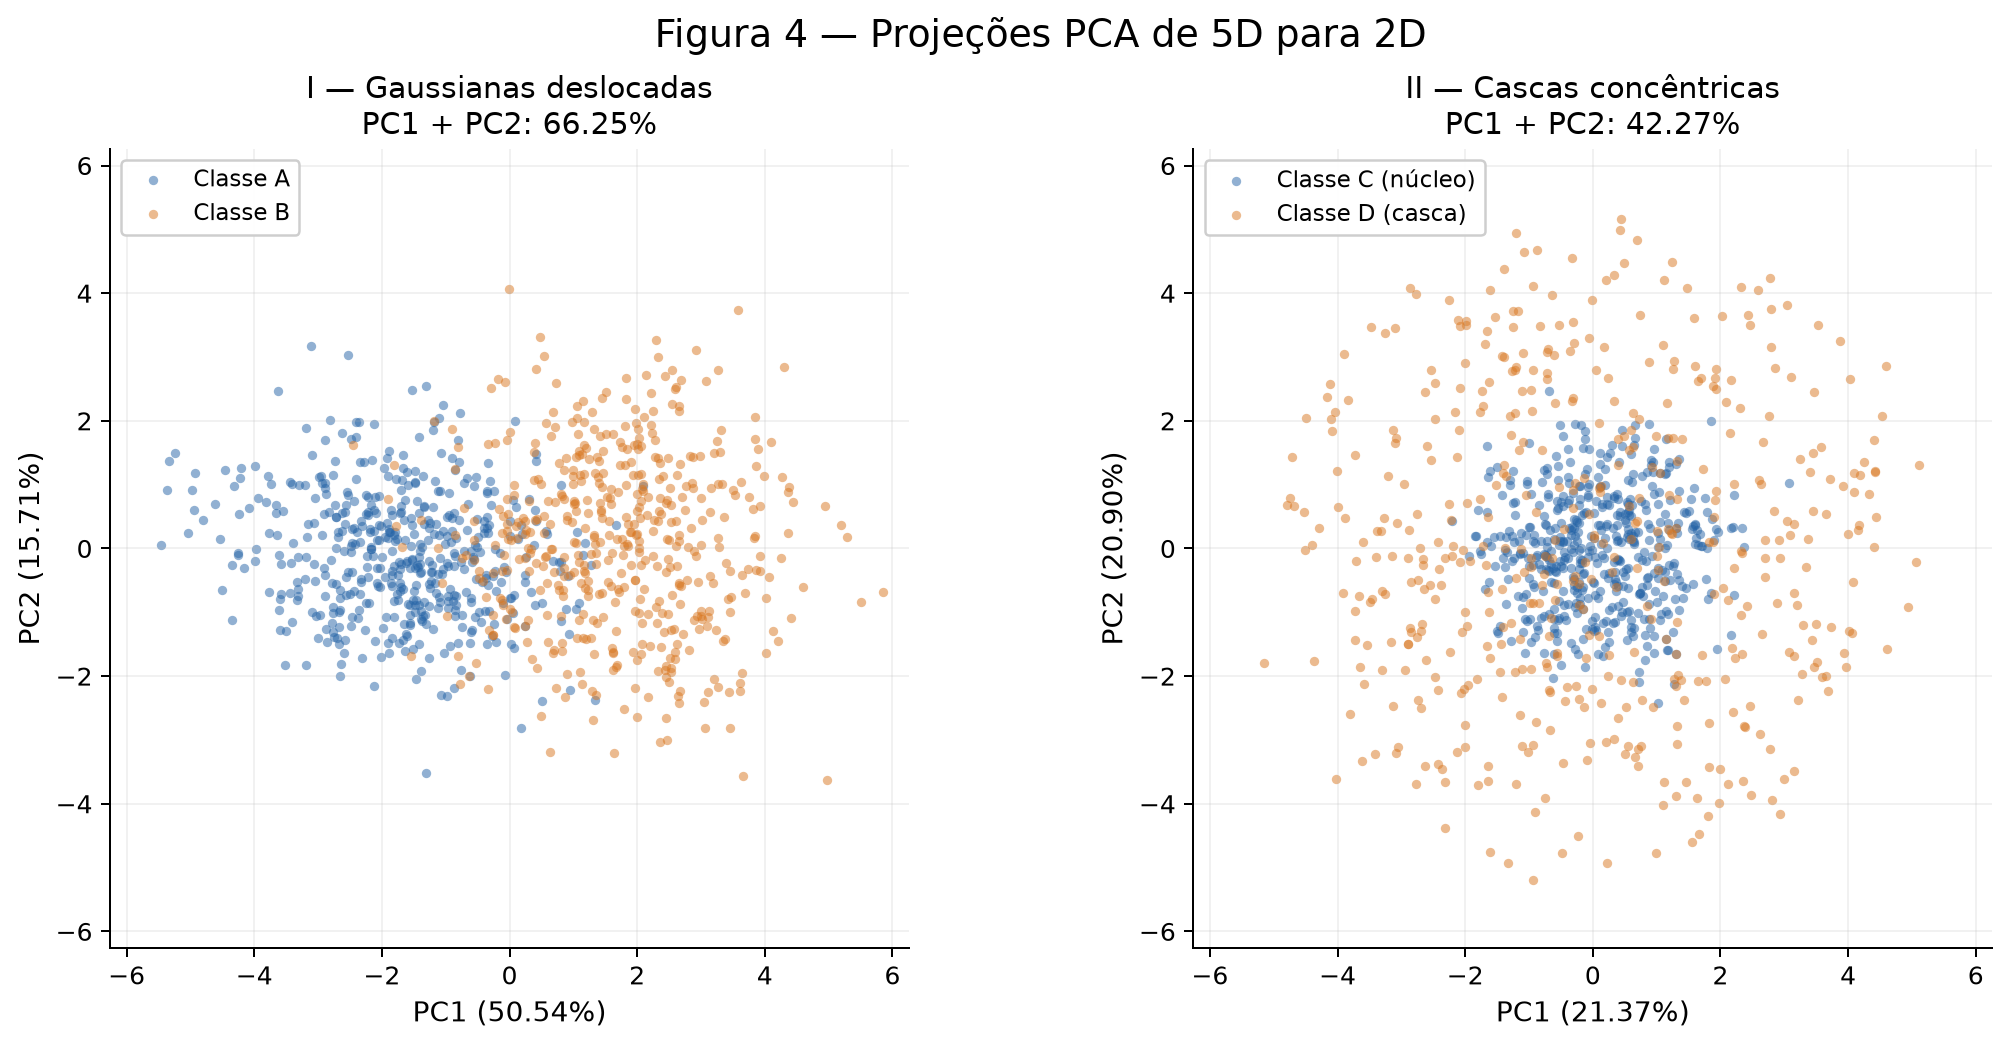

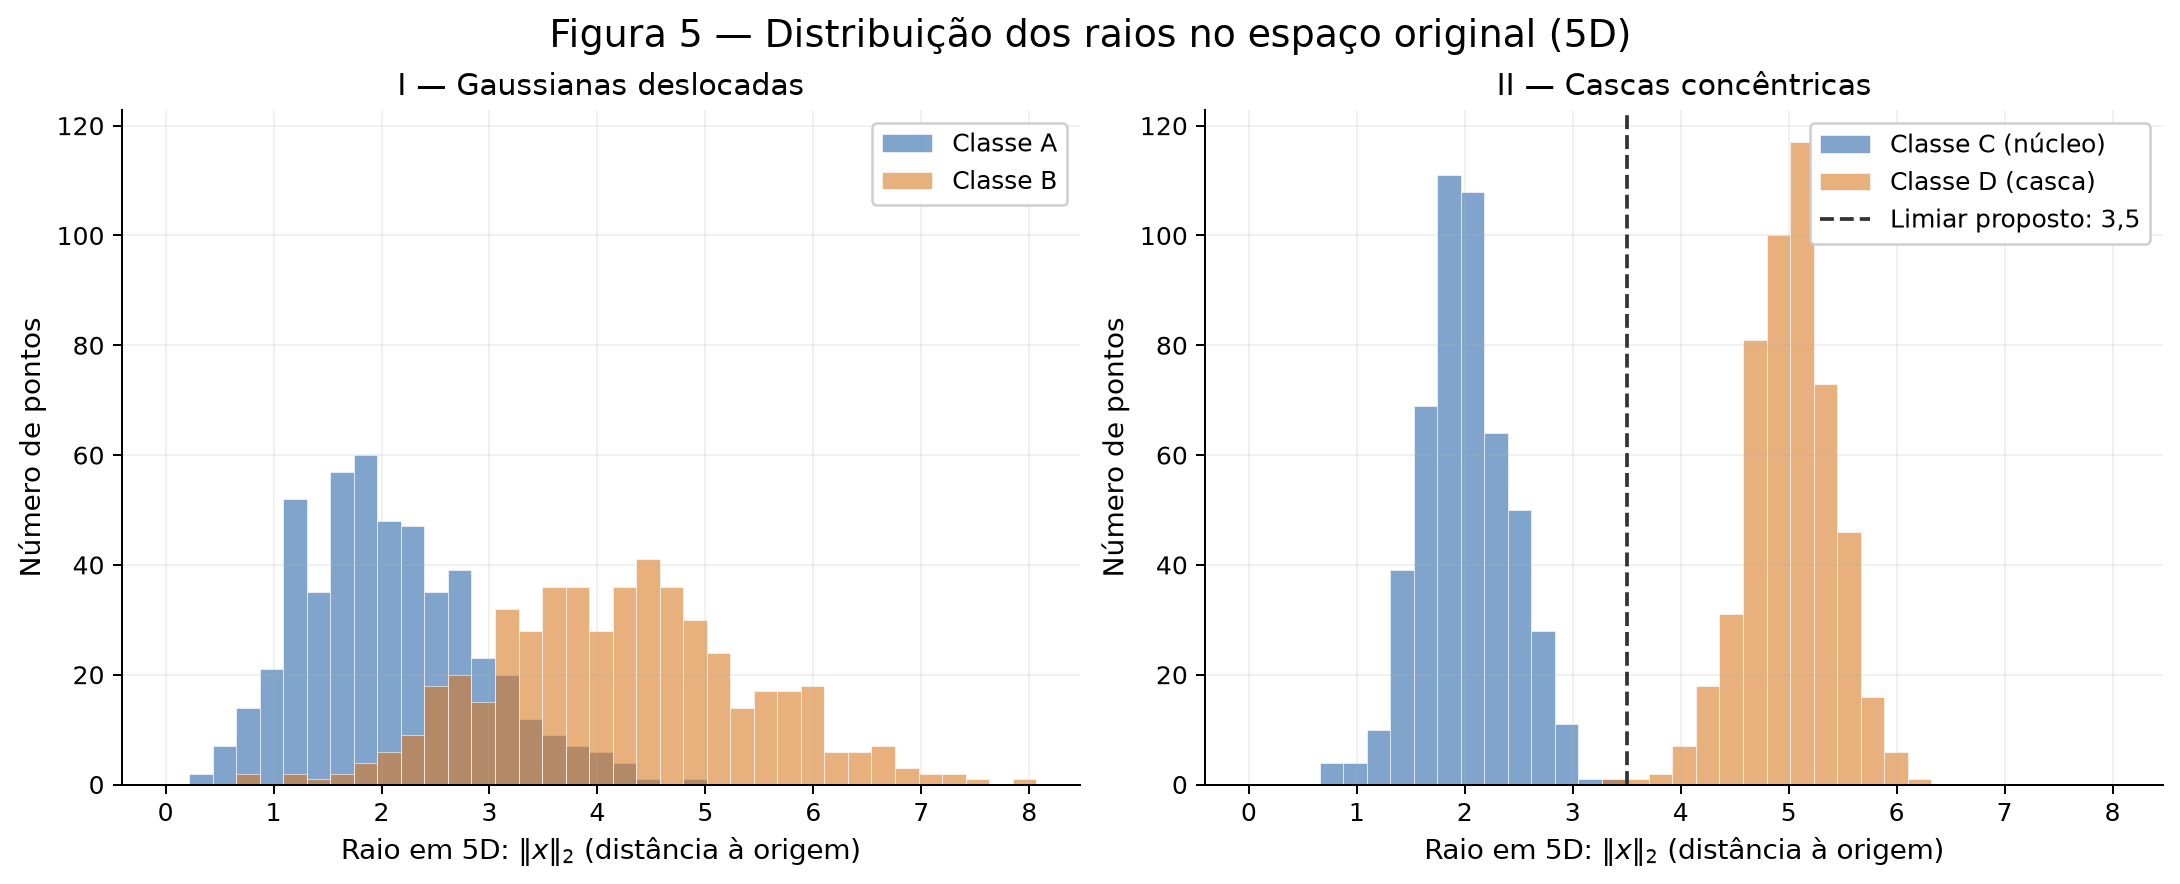

In [7]:
pca_I = PCA(n_components=2, svd_solver="full")
pca_II = PCA(n_components=2, svd_solver="full")
Z_I = pca_I.fit_transform(X_I)
Z_II = pca_II.fit_transform(X_II)
dist_I = float(np.linalg.norm(X_A.mean(axis=0) - X_B.mean(axis=0)))
dist_II = float(np.linalg.norm(X_C.mean(axis=0) - X_D.mean(axis=0)))
dist_I_teorica = float(np.linalg.norm(mu_A - mu_B))
variancia_I = pca_I.explained_variance_ratio_
variancia_II = pca_II.explained_variance_ratio_
raios_I = np.linalg.norm(X_I, axis=1)
raios_II = np.linalg.norm(X_II, axis=1)
metricas_5d = pd.DataFrame({
    "Dataset": ["I", "II"],
    "Distância amostral (5D)": [dist_I, dist_II],
    "Distância populacional": [dist_I_teorica, 0.0],
    "PC1 (%)": [100 * variancia_I[0], 100 * variancia_II[0]],
    "PC2 (%)": [100 * variancia_I[1], 100 * variancia_II[1]],
    "PC1 + PC2 (%)": [100 * variancia_I.sum(), 100 * variancia_II.sum()],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5.7), sharex=True, sharey=True,
                         layout="constrained")
lim_pca = max(np.abs(Z_I).max(), np.abs(Z_II).max()) + 0.4
for ax, Z, y, nomes, titulo, var in [
    (axes[0], Z_I, y_I, ["A", "B"], "I — Gaussianas deslocadas", variancia_I),
    (axes[1], Z_II, y_II, ["C (núcleo)", "D (casca)"], "II — Cascas concêntricas", variancia_II),
]:
    for k, nome in enumerate(nomes):
        ax.scatter(*Z[y == k].T, c=CORES[k], s=14, alpha=0.5,
                   linewidths=0, label=f"Classe {nome}")
    ax.set(title=f"{titulo}\nPC1 + PC2: {100*var.sum():.2f}%",
           xlabel=f"PC1 ({100*var[0]:.2f}%)", ylabel=f"PC2 ({100*var[1]:.2f}%)",
           xlim=(-lim_pca, lim_pca), ylim=(-lim_pca, lim_pca))
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(labelleft=True)
    ax.legend(loc="upper left", fontsize=9)
fig.suptitle("Figura 4 — Projeções PCA de 5D para 2D", fontsize=15)
salvar_figura(fig, 4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True,
                         layout="constrained")
bins = np.linspace(0, max(raios_I.max(), raios_II.max()) + 0.1, 38)
for ax, raios, y, nomes, titulo in [
    (axes[0], raios_I, y_I, ["A", "B"], "I — Gaussianas deslocadas"),
    (axes[1], raios_II, y_II, ["C (núcleo)", "D (casca)"], "II — Cascas concêntricas"),
]:
    for k, nome in enumerate(nomes):
        ax.hist(raios[y == k], bins=bins, color=CORES[k], alpha=0.58,
                label=f"Classe {nome}", edgecolor="white", linewidth=0.4)
    ax.set(title=titulo, xlabel=r"Raio em 5D: $\|x\|_2$ (distância à origem)",
           ylabel="Número de pontos")
    ax.tick_params(labelleft=True)
    ax.legend()
axes[1].axvline(3.5, color="#333333", ls="--", label="Limiar proposto: 3,5")
axes[1].legend()
fig.suptitle("Figura 5 — Distribuição dos raios no espaço original (5D)", fontsize=15)
salvar_figura(fig, 5)
print(metricas_5d.to_string(index=False))

| Dataset | Distância amostral (5D) | Distância populacional | PC1 (%) | PC2 (%) | PC1 + PC2 (%) |
| --- | --- | --- | --- | --- | --- |
| I | 3,3988 | 3,3541 | 50,5397 | 15,7055 | 66,2453 |
| II | 0,2215 | 0,0000 | 21,3742 | 20,8998 | 42,2740 |

No Dataset I, **PC1 explica 50,5397%** e
**PC2 explica 15,7055%**, totalizando
**66,2453%**. No Dataset II, os valores são
**21,3742%**, **20,8998%** e
**42,2740%**, respectivamente.

As distâncias amostrais entre centros em 5D são **3,3988 no Dataset I**
e **0,2215 no Dataset II**. Pelos parâmetros populacionais, elas são
$1,5\sqrt{5}=$ **3,3541** e **0**, respectivamente;
o pequeno deslocamento entre C e D é efeito do tamanho finito da amostra.

**A projeção 2D preserva melhor a informação útil no Dataset I**, neste experimento:
o deslocamento das médias contribui para uma direção de grande variância,
parcialmente preservada pela PCA. No Dataset II, a informação discriminante está
no raio em todas as cinco coordenadas, enquanto a orientação é isotrópica;
descartar três coordenadas permite que pontos da casca externa se projetem perto
do núcleo. A maior variância explicada, sozinha, não provaria melhor classificação:
a conclusão combina essa medida, o deslocamento dos centros e a geometria observada.

### D — Análise

No Dataset II, centros quase coincidentes junto com raios bem distintos indicam
que **a distância à origem discrimina as classes, e a direção não**. Um hiperplano
$w^Tx+b=0$ seleciona lados do espaço e não consegue colocar um núcleo esférico
inteiro de um lado e uma casca que o envolve do outro. Pela simetria, os pontos
$ru$ e $-ru$ de uma mesma esfera aparecem em lados opostos de um plano que passa
pelo centro; deslocar o plano tampouco cria uma região interna fechada.
Equivalentemente, o fecho convexo da casca contém o núcleo. Mais observações
preenchem as direções e não removem essa obstrução geométrica.

Centros coincidentes, isoladamente, não seriam uma demonstração suficiente para
uma amostra qualquer. Aqui a conclusão usa também a **simetria radial e a estrutura
concêntrica**. Além disso, os raios normais têm caudas infinitas: mesmo uma fronteira
não linear não promete erro populacional exatamente zero. Isso é diferente da
impossibilidade estrutural de resolver as cascas com um único hiperplano.

Uma projeção linear 2D em que há mistura **não prova inseparabilidade no espaço
original**: ela descarta informações, podendo sobrepor pontos originalmente
distintos. O próprio Dataset II apresenta mistura visual na Figura 4 e separação
radial nítida na Figura 5. Uma função simples que usa essa informação é

$$g(x)=\sum_{i=1}^{5}x_i^2-3,5^2=\sum_{i=1}^{5}x_i^2-12,25.$$

Atribuo C se $g(x)<0$ e D se $g(x)\geq0$. O raio 3,5 é o ponto médio entre os
raios médios 2 e 5 fornecidos pelo enunciado; não foi ajustado aos dados.
A função é quadrática nas entradas originais, embora uma comparação linear
seja suficiente **depois** de criar a feature não linear $z=\sum_i x_i^2$.

In [8]:
def regra_radial(X):
    # Regra analítica, sem fit: 0 = C; 1 = D.
    return ((X ** 2).sum(axis=1) >= 3.5 ** 2).astype(int)

erros_radiais = int((regra_radial(X_II) != y_II).sum())
intervalos_raio = pd.DataFrame([
    {"Classe": nome, "Raio mínimo": np.linalg.norm(X, axis=1).min(),
     "Raio médio": np.linalg.norm(X, axis=1).mean(),
     "Raio máximo": np.linalg.norm(X, axis=1).max()}
    for nome, X in [("A", X_A), ("B", X_B), ("C", X_C), ("D", X_D)]
])
print(intervalos_raio.to_string(index=False))
print("Erros da regra radial na amostra do Dataset II:", erros_radiais, "/ 1000")

# Exemplo geométrico adicional: 11 fica entre o maior raio ao quadrado de C
# e o menor de D nesta amostra. Não é um desempenho de generalização.
def separador_da_amostra(X):
    return ((X ** 2).sum(axis=1) >= 11.0).astype(int)

maior_raio_C = float(np.linalg.norm(X_C, axis=1).max())
menor_raio_D = float(np.linalg.norm(X_D, axis=1).min())
assert maior_raio_C**2 < 11.0 < menor_raio_D**2
erros_separador_amostra = int((separador_da_amostra(X_II) != y_II).sum())
print("Erros com o limiar ilustrativo ||x||² = 11:", erros_separador_amostra, "/ 1000")

Classe  Raio mínimo  Raio médio  Raio máximo
     A     0.294453    2.066587     4.972191
     B     0.667874    4.207677     7.964016
     C     0.752210    2.003860     3.279577
     D     3.444878    5.017539     6.240259
Erros da regra radial na amostra do Dataset II: 1 / 1000
Erros com o limiar ilustrativo ||x||² = 11: 0 / 1000


| Classe | Raio mínimo | Raio médio | Raio máximo |
| --- | --- | --- | --- |
| A | 0,2945 | 2,0666 | 4,9722 |
| B | 0,6679 | 4,2077 | 7,9640 |
| C | 0,7522 | 2,0039 | 3,2796 |
| D | 3,4449 | 5,0175 | 6,2403 |

A regra radial com limiar 3,5 cometeu **1 erros em 1.000 pontos**
do Dataset II (**0,10%**).
Este é um diagnóstico geométrico da amostra gerada, sem treinamento ou avaliação
de generalização. A distância entre centros não capta essa informação: apesar
de valer apenas **0,2215**, as classes se distinguem pelo raio.

**Uma função que separa todos os pontos desta amostra** é
$g_{amostra}(x)=\sum_i x_i^2-11$: retorna C para valor negativo e D caso contrário.
Com ela, há **0 erros em 1.000 pontos**. Isso é possível
porque o maior raio de C é **3,2796** e o menor raio de D é
**3,4449**; $\sqrt{11}\approx3,3166$ fica dentro desse vão.
O limiar 11 foi escolhido para ilustrar o vão observado, ao passo que 3,5 foi
derivado dos parâmetros do enunciado. A primeira demonstração é específica da
amostra e não fornece uma garantia para novos pontos; não houve treinamento
de rede ou de qualquer modelo estimado por algoritmo.

## Exercício 3

### A — Conheça os dados

O **Spaceship Titanic** é uma tarefa de classificação binária: `Transported=True`
indica que o passageiro foi transportado para outra dimensão durante o encontro
da nave com uma anomalia. As demais colunas descrevem o passageiro e seus gastos.
Fonte do objetivo e do dicionário de dados:
[Kaggle — Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic/data).

O download direto do Kaggle pede autenticação e aceite das regras. Para executar
esta atividade, usei uma
[cópia pública do train.csv](https://github.com/You-sha/Spaceship-Titanic/blob/main/train.csv),
conferida byte a byte por SHA-256 contra
[uma segunda cópia pública](https://github.com/AmirFARES/Kaggle-Spaceship-Titanic/blob/main/data/train.csv).
Os hashes são iguais. Trata-se do arquivo **rotulado `train.csv`**; o `test.csv`
da competição não é utilizado. O teste deste relatório é reservado desse arquivo
rotulado, conforme o split 80/20 solicitado.

As features originais se dividem assim:

| Tipo | Colunas | Tratamento |
| --- | --- | --- |
| Numéricas | `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` | Imputação e escala; log nos gastos |
| Categóricas | `HomePlanet`, `CryoSleep`, `Destination`, `VIP` | Imputação e one-hot |
| Categóricas estruturadas / identificadores / texto | `Cabin`, `PassengerId`, `Name` | Descartadas, conforme o enunciado |
| Alvo binário | `Transported` | Separado das features; False=0 e True=1 |

As estatísticas descritivas do item A são do arquivo inteiro e excluem faltantes
em cada coluna. Elas atendem à descrição pedida e **não alimentam as transformações**.
Para deixar a separação explícita, os índices de treino e teste já são reservados
logo após a leitura, antes dessas estatísticas; o item B detalha o procedimento.

In [9]:
arquivo = EXERCISE_DIR / "data/train.csv"
hash_esperado = "17336d553f49ebdf6ecb266d2b5d3746e5dd308445f7c7864141c4f28d2a88d0"
hash_obtido = hashlib.sha256(arquivo.read_bytes()).hexdigest()
assert hash_obtido == hash_esperado, "Arquivo diferente da cópia usada no relatório."
df = pd.read_csv(arquivo)
assert df.shape == (8693, 14)
assert df["PassengerId"].is_unique
assert not df["Transported"].isna().any()
y_real = df["Transported"].astype(int)

def split_estratificado(y, proporcao_teste=0.2):
    # Estratificação com o MESMO rng; sklearn fica restrito à PCA e ao
    # pré-processamento. Maiores restos resolvem o arredondamento das cotas.
    classes, contagens = np.unique(y, return_counts=True)
    cotas = proporcao_teste * contagens
    n_testes = np.floor(cotas).astype(int)
    total_teste = int(np.ceil(len(y) * proporcao_teste))
    faltam = total_teste - n_testes.sum()
    ordem_restos = np.argsort(-(cotas - n_testes), kind="stable")
    n_testes[ordem_restos[:faltam]] += 1
    treino, teste = [], []
    for classe, n_teste in zip(classes, n_testes):
        indices = rng.permutation(np.flatnonzero(np.asarray(y) == classe))
        teste.extend(indices[:n_teste])
        treino.extend(indices[n_teste:])
    return rng.permutation(treino), rng.permutation(teste)

# A reserva ocorre antes de qualquer imputação, codificação ou escala.
idx_treino, idx_teste = split_estratificado(y_real)
treino_bruto = df.iloc[idx_treino].copy()
teste_bruto = df.iloc[idx_teste].copy()
y_treino = y_real.iloc[idx_treino].to_numpy()
y_teste = y_real.iloc[idx_teste].to_numpy()

gastos = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
numericas_originais = ["Age"] + gastos
categoricas = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
balanceamento = pd.DataFrame({
    "Transported": ["False (0)", "True (1)"],
    "Contagem": [(y_real == 0).sum(), (y_real == 1).sum()],
    "Percentual (%)": [100 * (y_real == 0).mean(), 100 * (y_real == 1).mean()],
})
faltantes = pd.DataFrame({"Coluna": df.columns,
                         "Faltantes": df.isna().sum().to_numpy(),
                         "Percentual (%)": 100 * df.isna().mean().to_numpy()})
estat_gastos = df[gastos].agg(["mean", "median", "max"]).T.reset_index()
estat_gastos.columns = ["Coluna", "Média", "Mediana", "Máximo"]
print("SHA-256:", hash_obtido)
print(balanceamento.to_string(index=False))
print(faltantes.to_string(index=False))
print(estat_gastos.to_string(index=False))

SHA-256: 17336d553f49ebdf6ecb266d2b5d3746e5dd308445f7c7864141c4f28d2a88d0
Transported  Contagem  Percentual (%)
  False (0)      4315       49.637639
   True (1)      4378       50.362361
      Coluna  Faltantes  Percentual (%)
 PassengerId          0        0.000000
  HomePlanet        201        2.312205
   CryoSleep        217        2.496261
       Cabin        199        2.289198
 Destination        182        2.093639
         Age        179        2.059128
         VIP        203        2.335212
 RoomService        181        2.082135
   FoodCourt        183        2.105142
ShoppingMall        208        2.392730
         Spa        183        2.105142
      VRDeck        188        2.162660
        Name        200        2.300702
 Transported          0        0.000000
      Coluna      Média  Mediana  Máximo
 RoomService 224.687617      0.0 14327.0
   FoodCourt 458.077203      0.0 29813.0
ShoppingMall 173.729169      0.0 23492.0
         Spa 311.138778      0.0 22408.0
      V

O arquivo contém **8693 passageiros** e **14 colunas**, sendo 13 features
originais e um alvo. A classe positiva tem **4378 passageiros
(50,3624%)**, e a negativa tem
**4315 (49,6376%)**.
Logo, o alvo está aproximadamente balanceado.

| Transported | Contagem | Percentual (%) |
| --- | --- | --- |
| False (0) | 4315 | 49,6376 |
| True (1) | 4378 | 50,3624 |

**Valores faltantes, por coluna (arquivo inteiro):**

| Coluna | Faltantes | Percentual (%) |
| --- | --- | --- |
| PassengerId | 0 | 0,0000 |
| HomePlanet | 201 | 2,3122 |
| CryoSleep | 217 | 2,4963 |
| Cabin | 199 | 2,2892 |
| Destination | 182 | 2,0936 |
| Age | 179 | 2,0591 |
| VIP | 203 | 2,3352 |
| RoomService | 181 | 2,0821 |
| FoodCourt | 183 | 2,1051 |
| ShoppingMall | 208 | 2,3927 |
| Spa | 183 | 2,1051 |
| VRDeck | 188 | 2,1627 |
| Name | 200 | 2,3007 |
| Transported | 0 | 0,0000 |

Há **2324 células faltantes** no arquivo; o alvo tem **0**.

**Gastos antes de qualquer transformação (arquivo inteiro; NaN ignorado):**

| Coluna | Média | Mediana | Máximo |
| --- | --- | --- | --- |
| RoomService | 224,69 | 0,00 | 14327,00 |
| FoodCourt | 458,08 | 0,00 | 29813,00 |
| ShoppingMall | 173,73 | 0,00 | 23492,00 |
| Spa | 311,14 | 0,00 | 22408,00 |
| VRDeck | 304,85 | 0,00 | 24133,00 |

As cinco medianas são **zero**, enquanto as médias são positivas e os máximos
ficam muito acima delas. Isso indica muitos passageiros sem gasto e uma minoria
com gastos elevados: há forte assimetria à direita e grande dispersão na cauda.
Em `FoodCourt`, por exemplo, média = **458,08**,
mediana = **0,00** e máximo =
**29813,00**. A média é puxada pelos gastos altos;
não representa o passageiro típico. Uso “cauda pesada” no sentido exploratório
do enunciado, sem afirmar uma família probabilística específica.

### B — Separe antes de transformar

O split implementado acima embaralha separadamente os índices de cada classe
com o mesmo `rng`, reserva aproximadamente 20% de cada uma para teste e embaralha
os dois conjuntos resultantes. O total de teste é arredondado para cima; as cotas
por classe usam os maiores restos, mantendo as proporções tão próximas quanto
possível. Não se usa um segundo gerador nem `train_test_split`.

A separação precede a imputação e o escalonamento porque medianas, extremos e
categorias aprendidas no arquivo inteiro levariam informação do teste para o
treino. Ajustar os transformadores exclusivamente no treino mantém o teste como
uma aproximação de dados ainda não vistos, à qual se aplicam os mesmos parâmetros.
As estatísticas globais de A são somente descritivas, e nunca são reutilizadas
nos objetos de pré-processamento.

In [10]:
assert len(np.intersect1d(idx_treino, idx_teste)) == 0
assert np.array_equal(np.sort(np.r_[idx_treino, idx_teste]), np.arange(len(df)))
split_tabela = pd.DataFrame([
    {"Conjunto": nome, "Amostras": len(y), "False (0)": int((y == 0).sum()),
     "True (1)": int((y == 1).sum()), "Positivos (%)": 100 * y.mean()}
    for nome, y in [("Treino", y_treino), ("Teste", y_teste)]
])
food_media_treino = float(treino_bruto["FoodCourt"].mean())
food_mediana_treino = float(treino_bruto["FoodCourt"].median())
print(split_tabela.to_string(index=False))
print("FoodCourt no treino bruto — média:", food_media_treino,
      "; mediana:", food_mediana_treino)

Conjunto  Amostras  False (0)  True (1)  Positivos (%)
  Treino      6954       3452      3502      50.359505
   Teste      1739        863       876      50.373778
FoodCourt no treino bruto — média: 462.1447677836567 ; mediana: 0.0


| Conjunto | Amostras | False (0) | True (1) | Positivos (%) |
| --- | --- | --- | --- | --- |
| Treino | 6954 | 3452 | 3502 | 50,3595 |
| Teste | 1739 | 863 | 876 | 50,3738 |

São **6954 amostras de treino** e **1739 de teste**,
aproximadamente 80/20. A fração positiva é **50,3595% no
treino** e **50,3738% no teste**.
**No treino, antes de imputar ou transformar, `FoodCourt` tem média
462,1448 e mediana 0,0000**,
calculadas sobre valores observados. Estes são os números retomados no item 11
do resumo; diferem da descrição do arquivo completo apresentada em A.

### C — Pré-processe

**Faltantes numéricos.** Uso a mediana de cada coluna, aprendida somente no treino.
Ela resiste à influência dos gastos extremos; para os gastos a mediana de treino
é zero, e para `Age` preserva um valor central da distribuição observada.
Isso não prova que um gasto desconhecido era zero: é uma simplificação de imputação.

**Faltantes categóricos.** Uso a categoria explícita `Ausente`, preservando a
distinção entre não informado e categorias reais. A conversão de booleanos em
texto é apenas uma uniformização de tipo, sem estatística aprendida.
O imputador e o one-hot são ajustados no treino. `handle_unknown="ignore"`
representa uma categoria inédita no teste por zeros no bloco daquela feature,
sem criar nova coluna e sem refazer o ajuste. Categorias não são inferidas do teste.

**Engenharia de features.** Descarto `Cabin`, `Name` e `PassengerId` pela seleção
explícita das colunas permitidas. Depois de imputar os cinco gastos em unidades
originais, crio `TotalSpend` como sua soma; assim não somo gastos logarítmicos nem
confundo a soma parcial de valores observados com uma soma completa.

**Cauda pesada.** Aplico `np.log1p` aos cinco gastos e também a `TotalSpend`.
A transformação mantém zero em zero, comprime grandes valores e conserva a ordem,
sem aprender estatísticas. Isso reduz a dominância dos extremos antes da escala
e ajuda a evitar pré-ativações excessivas, nas quais `tanh` satura e seu gradiente
fica pequeno. O efeito em `FoodCourt` aparece na Figura 6 do item D.

**Escalonamento.** Escolho `MinMaxScaler(feature_range=(-1, 1), clip=True)` para
as sete features numéricas: `Age`, os cinco gastos em log e `TotalSpend` em log.
O mínimo e máximo de cada coluna vêm somente do treino. `clip=True` limita a
−1 ou 1 valores de teste que ultrapassem os extremos de treino, sem usar os
extremos do teste para ajustar a escala; reporto abaixo quantos são truncados.
One-hot permanece em 0/1, já contido no intervalo solicitado.

O intervalo de saída de `tanh` não impõe uma restrição matemática às entradas;
a escala escolhida é uma medida de condicionamento. Ela não garante ausência
de saturação, pois as pré-ativações também dependem de pesos e vieses.

In [11]:
# 1. Imputação numérica: estatísticas aprendidas somente no treino.
imputador_num = SimpleImputer(strategy="median")
treino_num = pd.DataFrame(
    imputador_num.fit_transform(treino_bruto[numericas_originais]),
    columns=numericas_originais, index=treino_bruto.index,
)
teste_num = pd.DataFrame(
    imputador_num.transform(teste_bruto[numericas_originais]),
    columns=numericas_originais, index=teste_bruto.index,
)
medianas_imputacao = pd.DataFrame({"Coluna": numericas_originais,
                                  "Mediana aprendida no treino": imputador_num.statistics_})

# 2. Soma em unidades monetárias originais, depois da imputação.
for frame in (treino_num, teste_num):
    frame["TotalSpend"] = frame[gastos].sum(axis=1)
numericas = numericas_originais + ["TotalSpend"]
gastos_com_total = gastos + ["TotalSpend"]
assert (treino_num[gastos_com_total] >= 0).all().all()
assert (teste_num[gastos_com_total] >= 0).all().all()

# 3. Log nos gastos individuais e totais; Age continua sem log.
treino_log, teste_log = treino_num.copy(), teste_num.copy()
treino_log[gastos_com_total] = np.log1p(treino_num[gastos_com_total])
teste_log[gastos_com_total] = np.log1p(teste_num[gastos_com_total])

# 4. Min-max: um único fit, só no treino. Teste usa apenas transform.
escalonador = MinMaxScaler(feature_range=(-1, 1), clip=True)
treino_escalado = escalonador.fit_transform(treino_log)
teste_escalado = escalonador.transform(teste_log)
# Diagnóstico de clipping com os mesmos parâmetros aprendidos.
teste_sem_clip = teste_log.to_numpy() * escalonador.scale_ + escalonador.min_
clip_mask = (teste_sem_clip < -1 - 1e-12) | (teste_sem_clip > 1 + 1e-12)
clip_colunas = pd.DataFrame({"Coluna": numericas,
                             "Células do teste truncadas": clip_mask.sum(axis=0)})

# 5. Tipo uniforme por coluna categórica, preservando faltantes como np.nan.
def preparar_categoricas(frame):
    cat = frame[categoricas].astype("string").astype(object)
    return cat.where(pd.notna(cat), np.nan)

imputador_cat = SimpleImputer(strategy="constant", fill_value="Ausente")
treino_cat = imputador_cat.fit_transform(preparar_categoricas(treino_bruto))
teste_cat = imputador_cat.transform(preparar_categoricas(teste_bruto))
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float64)
treino_onehot = encoder.fit_transform(treino_cat)
teste_onehot = encoder.transform(teste_cat)
nomes_onehot = encoder.get_feature_names_out(categoricas).tolist()

# 6. Matrizes finais: sete colunas numéricas e os blocos one-hot.
nomes_features = numericas + nomes_onehot
X_treino_final = np.column_stack([treino_escalado, treino_onehot])
X_teste_final = np.column_stack([teste_escalado, teste_onehot])
categorias_aprendidas = pd.DataFrame({
    "Feature": categoricas,
    "Categorias vistas no treino": [", ".join(c) for c in encoder.categories_],
    "Número de colunas one-hot": [len(c) for c in encoder.categories_],
})
ineditas_teste = {
    col: sorted(set(teste_cat[:, j]) - set(encoder.categories_[j]))
    for j, col in enumerate(categoricas)
}

# Verifica o contrato para uma categoria inédita sem mudar nem reajustar dados.
exemplo_inedito = teste_cat[:1].copy()
exemplo_inedito[0, 0] = "Planeta_inedito"
codificado_inedito = encoder.transform(exemplo_inedito)
assert (codificado_inedito[0, :len(encoder.categories_[0])] == 0).all()

intervalos_finais = pd.DataFrame([
    {"Conjunto": nome, "Mínimo numérico": Xn.min(), "Máximo numérico": Xn.max(),
     "Mínimo da matriz final": X.min(), "Máximo da matriz final": X.max()}
    for nome, Xn, X in [("Treino", treino_escalado, X_treino_final),
                        ("Teste", teste_escalado, X_teste_final)]
])
print(medianas_imputacao.to_string(index=False))
print(categorias_aprendidas.to_string(index=False))
print("Categorias inéditas no teste real:", ineditas_teste)
print(clip_colunas.to_string(index=False))
print(intervalos_finais.to_string(index=False))

      Coluna  Mediana aprendida no treino
         Age                         27.0
 RoomService                          0.0
   FoodCourt                          0.0
ShoppingMall                          0.0
         Spa                          0.0
      VRDeck                          0.0
    Feature                      Categorias vistas no treino  Número de colunas one-hot
 HomePlanet                     Ausente, Earth, Europa, Mars                          4
  CryoSleep                             Ausente, False, True                          3
Destination 55 Cancri e, Ausente, PSO J318.5-22, TRAPPIST-1e                          4
        VIP                             Ausente, False, True                          3
Categorias inéditas no teste real: {'HomePlanet': [], 'CryoSleep': [], 'Destination': [], 'VIP': []}
      Coluna  Células do teste truncadas
         Age                           0
 RoomService                           0
   FoodCourt                           1
S

**Medianas usadas na imputação numérica:**

| Coluna | Mediana aprendida no treino |
| --- | --- |
| Age | 27,00 |
| RoomService | 0,00 |
| FoodCourt | 0,00 |
| ShoppingMall | 0,00 |
| Spa | 0,00 |
| VRDeck | 0,00 |

**Categorias e dimensões aprendidas exclusivamente no treino:**

| Feature | Categorias vistas no treino | Número de colunas one-hot |
| --- | --- | --- |
| HomePlanet | Ausente, Earth, Europa, Mars | 4 |
| CryoSleep | Ausente, False, True | 3 |
| Destination | 55 Cancri e, Ausente, PSO J318.5-22, TRAPPIST-1e | 4 |
| VIP | Ausente, False, True | 3 |

No teste reservado, há **0 categorias
inéditas** entre as quatro features. O código também verifica uma entrada artificial
`Planeta_inedito`: o bloco de `HomePlanet` é convertido em zeros, mantendo o mesmo
número de features. Esse exemplo verifica o tratamento de uma categoria nova;
não é incluído na matriz de teste.

**Intervalos depois do escalonamento e da concatenação:**

| Conjunto | Mínimo numérico | Máximo numérico | Mínimo da matriz final | Máximo da matriz final |
| --- | --- | --- | --- | --- |
| Treino | -1,000000 | 1,000000 | -1,000000 | 1,000000 |
| Teste | -1,000000 | 1,000000 | -1,000000 | 1,000000 |

As features numéricas e as matrizes completas têm **mínimo
-1,000000 e máximo 1,000000 no treino**;
no teste, **mínimo -1,000000 e máximo
1,000000**. O one-hot ocupa apenas 0 e 1.

Antes do clipping, o intervalo numérico do teste seria
**[-1,000000, 1,014209]**.
Foram truncadas **1 células numéricas** em
**1 passageiros de teste**, distribuídas assim:

| Coluna | Células do teste truncadas |
| --- | --- |
| Age | 0 |
| RoomService | 0 |
| FoodCourt | 1 |
| ShoppingMall | 0 |
| Spa | 0 |
| VRDeck | 0 |
| TotalSpend | 0 |

O truncamento torna o intervalo garantido, mas perde a distinção entre valores
que ultrapassam o mesmo extremo. O log reduz a influência da cauda antes desse
passo. A escolha e seus limites foram fixados sem ajustar parâmetros no teste.

### D — Verifique e visualize

A Figura 6 usa apenas passageiros do **treino**, coloridos por `Transported`.
O primeiro painel mostra os gastos observados, omitindo somente os NaN dessa
feature; o segundo mostra o efeito da imputação e do log; o terceiro mostra a
feature final após normalização. Os dois painéis posteriores incluem os valores
imputados. As contagens no eixo vertical usam escala logarítmica para tornar a
cauda visível, e isso está indicado no rótulo; a transformação `log1p` da feature
ocorre no eixo horizontal do painel intermediário.

Conjunto      shape  NaN  Infinitos  Mínimo  Máximo
  Treino (6954, 21)    0          0    -1.0     1.0
   Teste (1739, 21)    0          0    -1.0     1.0
Ordem final das features: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'HomePlanet_Ausente', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'CryoSleep_Ausente', 'CryoSleep_False', 'CryoSleep_True', 'Destination_55 Cancri e', 'Destination_Ausente', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP_Ausente', 'VIP_False', 'VIP_True']


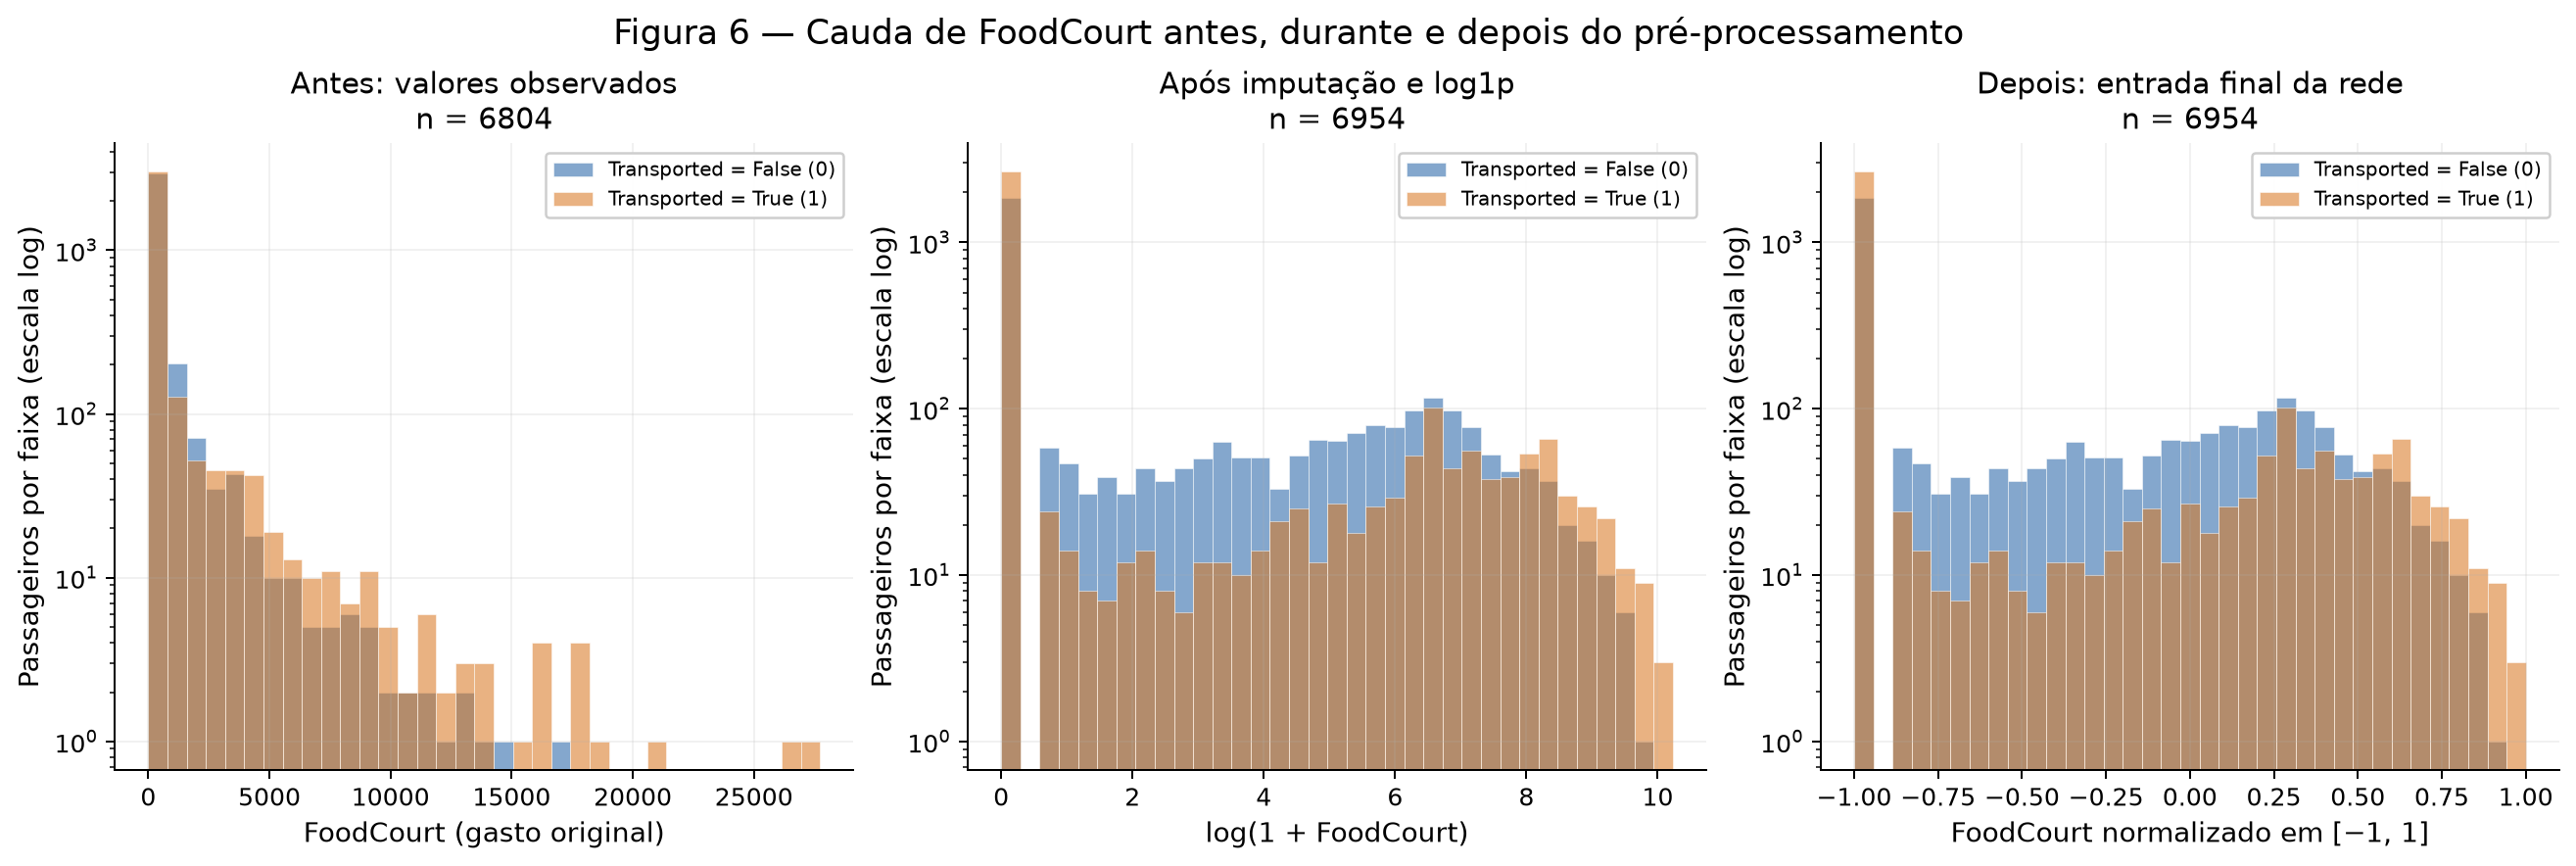

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), layout="constrained")
food_j = numericas.index("FoodCourt")
painel_dados = [
    (treino_bruto["FoodCourt"].to_numpy(), "Antes: valores observados", "FoodCourt (gasto original)"),
    (treino_log["FoodCourt"].to_numpy(), "Após imputação e log1p", "log(1 + FoodCourt)"),
    (treino_escalado[:, food_j], "Depois: entrada final da rede", "FoodCourt normalizado em [−1, 1]"),
]
for ax, (valores, titulo, rotulo) in zip(axes, painel_dados):
    validos = np.isfinite(valores)
    bins = np.linspace(valores[validos].min(), valores[validos].max(), 36)
    for k, nome in [(0, "False (0)"), (1, "True (1)")]:
        ax.hist(valores[validos & (y_treino == k)], bins=bins, alpha=0.56,
                color=CORES[k], label=f"Transported = {nome}",
                edgecolor="white", linewidth=0.35)
    ax.set(yscale="log", xlabel=rotulo, ylabel="Passageiros por faixa (escala log)",
           title=titulo + f"\nn = {validos.sum()}")
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Figura 6 — Cauda de FoodCourt antes, durante e depois do pré-processamento",
             fontsize=14)
salvar_figura(fig, 6)

# Checagens necessárias para preparar a entrada da rede, sem treinar modelos.
assert np.array_equal(imputador_num.statistics_,
                      treino_bruto[numericas_originais].median().to_numpy())
assert np.allclose(escalonador.data_min_, treino_log.min().to_numpy())
assert np.allclose(escalonador.data_max_, treino_log.max().to_numpy())
assert np.allclose(treino_num["TotalSpend"], treino_num[gastos].sum(axis=1))
assert np.allclose(teste_num["TotalSpend"], teste_num[gastos].sum(axis=1))
for j, cats in enumerate(encoder.categories_):
    assert set(cats) == set(treino_cat[:, j])
for X, y in [(X_treino_final, y_treino), (X_teste_final, y_teste)]:
    assert X.shape[0] == len(y)
    assert X.shape[1] == len(nomes_features)
    assert np.isfinite(X).all()
    assert X.min() >= -1 - 1e-12 and X.max() <= 1 + 1e-12
assert X_treino_final.shape[1] == X_teste_final.shape[1]
assert not set(["Transported", "PassengerId", "Cabin", "Name"]) & set(nomes_features)

checagens = pd.DataFrame([
    {"Conjunto": nome, "shape": str(X.shape), "NaN": int(np.isnan(X).sum()),
     "Infinitos": int(np.isinf(X).sum()), "Mínimo": float(X.min()), "Máximo": float(X.max())}
    for nome, X in [("Treino", X_treino_final), ("Teste", X_teste_final)]
])
print(checagens.to_string(index=False))
print("Ordem final das features:", nomes_features)

# Saídas reutilizáveis e índices para auditar/reproduzir a divisão exata.
np.savez_compressed(OUT / "dados_preprocessados.npz", X_train=X_treino_final,
                    X_test=X_teste_final, y_train=y_treino, y_test=y_teste,
                    train_indices=idx_treino, test_indices=idx_teste,
                    feature_names=np.asarray(nomes_features, dtype=str))
pd.DataFrame(X_treino_final, columns=nomes_features).to_csv(OUT / "X_treino.csv", index=False)
pd.DataFrame(X_teste_final, columns=nomes_features).to_csv(OUT / "X_teste.csv", index=False)
pd.DataFrame({"indice_original": idx_treino, "Transported": y_treino}).to_csv(
    OUT / "y_treino.csv", index=False)
pd.DataFrame({"indice_original": idx_teste, "Transported": y_teste}).to_csv(
    OUT / "y_teste.csv", index=False)
faltantes.to_csv(OUT / "faltantes.csv", index=False)
rij.to_csv(OUT / "razoes_separacao.csv", index=False)
mistura.to_csv(OUT / "taxas_mistura.csv", index=False)
np.savez_compressed(OUT / "datasets_sinteticos.npz",
                    X_s05=datasets_2d[0.5], X_s1=datasets_2d[1.0],
                    X_s2=datasets_2d[2.0], X_s4=datasets_2d[4.0], y_2d=y_2d,
                    X_I=X_I, y_I=y_I, X_II=X_II, y_II=y_II)

| Conjunto | shape | NaN | Infinitos | Mínimo | Máximo |
| --- | --- | --- | --- | --- | --- |
| Treino | (6954, 21) | 0 | 0 | -1,000000 | 1,000000 |
| Teste | (1739, 21) | 0 | 0 | -1,000000 | 1,000000 |

**Checagens finais:** há **0 NaN e 0 infinitos** no treino e no teste.
O `shape` final é **(6954, 21) no treino** e
**(1739, 21) no teste**, com **7 features numéricas**
e **14 colunas one-hot**. Ambas as matrizes estão integralmente
em **[−1, 1]**, compatíveis com a escala de entrada escolhida para `tanh`.
Treino e teste têm as mesmas colunas e a mesma ordem; o alvo não está nas features.
Os testes também confirmaram índices disjuntos e parâmetros dos transformadores
iguais aos calculados exclusivamente no treino.

As decisões que mais afetariam o treinamento são o **log seguido da escala**,
pois gastos muito grandes poderiam dominar as combinações lineares e contribuir
para saturação de `tanh`, e a **codificação one-hot**, que evita impor uma ordem
numérica inexistente aos planetas ou destinos. A mediana e a categoria `Ausente`
permitem aproveitar linhas incompletas, mas introduzem hipóteses sobre os valores
desconhecidos; `TotalSpend` explicita o gasto agregado, embora seja redundante com
os gastos individuais antes do log. Separar antes dos ajustes protege a validade
de uma futura avaliação, e limitar os extremos do teste controla a escala ao
custo de perder informação além dos limites do treino. Sem treinar modelos,
essas são implicações esperadas das transformações, não ganhos de desempenho medidos.

In [13]:
resumo_metricas = {
    "taxas_mistura": {str(s): float(taxas[s]) for s in escalas},
    "menor_rij_s1": rmin, "par_menor_rij": par_min, "menor_rij_s2": rmin / 2,
    "primeira_escala_amostral_nao_separavel": float(primeiro_s),
    "distancia_centros_dataset_I": dist_I, "distancia_centros_dataset_II": dist_II,
    "variancia_explicada_dataset_I": variancia_I.tolist(),
    "variancia_explicada_dataset_II": variancia_II.tolist(),
    "proporcao_transportados": float(y_real.mean()),
    "foodcourt_media_treino": food_media_treino,
    "foodcourt_mediana_treino": food_mediana_treino,
    "shape_treino": list(X_treino_final.shape), "shape_teste": list(X_teste_final.shape),
    "intervalo_treino": [float(X_treino_final.min()), float(X_treino_final.max())],
    "intervalo_teste": [float(X_teste_final.min()), float(X_teste_final.max())],
    "nan_treino": int(np.isnan(X_treino_final).sum()),
    "nan_teste": int(np.isnan(X_teste_final).sum()),
    "celulas_teste_clipping": int(clip_mask.sum()), "erros_regra_radial": erros_radiais,
    "erros_separador_radial_da_amostra": erros_separador_amostra,
    "dataset_sha256": hash_obtido, "versoes": versoes,
}
(OUT / "metricas.json").write_text(json.dumps(resumo_metricas, indent=2, ensure_ascii=False),
                                  encoding="utf-8")

## Resumo dos resultados

As distâncias dos itens 6 e 7 usam centros amostrais em 5D. O item 13 inclui o clipping do teste especificado em 3C.

| # | Item | Seu valor |
| --- | --- | --- |
| 1 | Taxa de mistura em s=0.5 | 0,00% (0/400) |
| 2 | Taxa de mistura em s=1.0 | 5,00% (20/400) |
| 3 | Taxa de mistura em s=2.0 | 19,25% (77/400) |
| 4 | Taxa de mistura em s=4.0 | 48,25% (193/400) |
| 5 | Menor r_ij em s=1.0 e qual é o par | 1,3258; par (0, 1) |
| 6 | Distância entre os centros — Dataset I | 3,3988 |
| 7 | Distância entre os centros — Dataset II | 0,2215 |
| 8 | Variância explicada PC1 + PC2 — Dataset I | 66,2453% |
| 9 | Variância explicada PC1 + PC2 — Dataset II | 42,2740% |
| 10 | Proporção da classe positiva em Transported | 0,503624 (50,3624%) |
| 11 | Média e mediana de FoodCourt no treino, antes de transformar | Média 462,1448; mediana 0,0000 |
| 12 | shape final da matriz de features de treino | (6954, 21) |
| 13 | Mínimo e máximo do treino e do teste após o escalonamento | Treino [-1,0, 1,0]; teste [-1,0, 1,0] |